<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana12/ValidacaoOverfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações do Scikit-Learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_validate, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# =====================================================================
# 1. PREPARAÇÃO DOS DADOS (Dataset Real de Cancro da Mama)
# =====================================================================
# Carregar os dados reais
dados = load_breast_cancer()
X = pd.DataFrame(dados.data, columns=dados.feature_names)
y = pd.Series(dados.target) # 0 = Maligno, 1 = Benigno

# Divisão: Vamos usar 50% para teste para forçar o modelo a ter menos
# dados no treino, o que aumenta a probabilidade de overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

print(f"Dimensão do Treino: {X_train.shape}")
print(f"Dimensão do Teste: {X_test.shape}\n")

Dimensão do Treino: (284, 30)
Dimensão do Teste: (285, 30)



In [3]:
# =====================================================================
# 2. TREINO DO MODELO (Propositadamente propenso a Overfitting)
# =====================================================================
# Uma Árvore de Decisão sem max_depth vai crescer até memorizar o treino.
modelo = DecisionTreeClassifier(max_depth=None, random_state=42)
modelo.fit(X_train, y_train)

# Previsões para as duas bases
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

In [5]:
# =====================================================================
# MÉTODO 1: COMPARAÇÃO DIRETA DE MÉTRICAS (TREINO vs TESTE)
# =====================================================================
print("="*65)
print("MÉTODO 1: COMPARAÇÃO DE MÉTRICAS (TREINO vs TESTE)")
print("="*65)

def calcular_metricas(y_real, y_pred, nome_base):
    acc = accuracy_score(y_real, y_pred)
    prec = precision_score(y_real, y_pred)
    rec = recall_score(y_real, y_pred)
    f1 = f1_score(y_real, y_pred)
    print(f"[{nome_base}] -> Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1-Score: {f1:.3f}")
    return acc

acc_treino = calcular_metricas(y_train, y_pred_train, "TREINO")
acc_teste = calcular_metricas(y_test, y_pred_test, "TESTE ")

diferenca = acc_treino - acc_teste
print(f"\nDiferença de Accuracy (Treino - Teste): {diferenca:.3f} ({diferenca*100:.1f}%)")

# Num problema médico real, uma quebra de 5% já é muito preocupante
if diferenca > 0.05:
    print("ALERTA: Diferença acentuada! Forte indício de OVERFITTING. O modelo memorizou o treino.")
else:
    print("OK: O modelo parece estar a generalizar bem.")

print("\n")

MÉTODO 1: COMPARAÇÃO DE MÉTRICAS (TREINO vs TESTE)
[TREINO] -> Accuracy: 1.000 | Precision: 1.000 | Recall: 1.000 | F1-Score: 1.000
[TESTE ] -> Accuracy: 0.912 | Precision: 0.938 | Recall: 0.922 | F1-Score: 0.930

Diferença de Accuracy (Treino - Teste): 0.088 (8.8%)
ALERTA: Diferença acentuada! Forte indício de OVERFITTING. O modelo memorizou o treino.




In [6]:
# =====================================================================
# MÉTODO 2: VALIDAÇÃO CRUZADA (CROSS-VALIDATION)
# =====================================================================
print("="*65)
print("MÉTODO 2: VALIDAÇÃO CRUZADA (5-Folds no Treino)")
print("="*65)

cv_resultados = cross_validate(modelo, X_train, y_train, cv=5,
                               scoring='accuracy', return_train_score=True)

media_treino_cv = np.mean(cv_resultados['train_score'])
media_teste_cv = np.mean(cv_resultados['test_score'])
desvio_padrao_teste_cv = np.std(cv_resultados['test_score'])

print(f"Média Accuracy no Treino (CV): {media_treino_cv:.3f}")
print(f"Média Accuracy na Validação (CV): {media_teste_cv:.3f}")
print(f"Desvio Padrão na Validação (CV): {desvio_padrao_teste_cv:.3f}")

if (media_treino_cv - media_teste_cv) > 0.05:
    print("ALERTA: Na validação cruzada, o desempenho no treino é consistentemente superior à validação. Overfitting!")

print("\n")

MÉTODO 2: VALIDAÇÃO CRUZADA (5-Folds no Treino)
Média Accuracy no Treino (CV): 1.000
Média Accuracy na Validação (CV): 0.919
Desvio Padrão na Validação (CV): 0.015
ALERTA: Na validação cruzada, o desempenho no treino é consistentemente superior à validação. Overfitting!




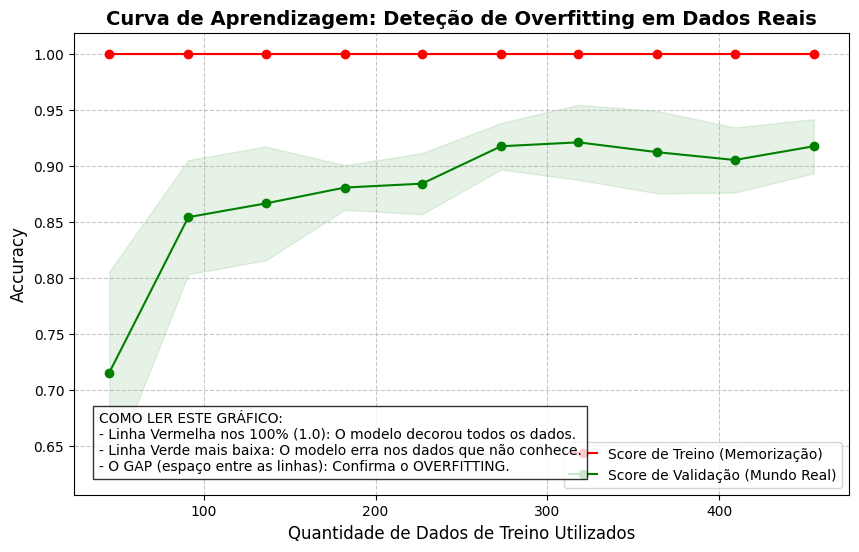

In [7]:
# =====================================================================
# MÉTODO 3: CURVAS DE APRENDIZAGEM (LEARNING CURVES) - VISUAL
# =====================================================================
# Calcula a performance do modelo à medida que lhe damos mais dados
train_sizes, train_scores, test_scores = learning_curve(
    modelo, X, y, cv=5, scoring='accuracy',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="red", label="Score de Treino (Memorização)")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Score de Validação (Mundo Real)")

# Sombreamento
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="red")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="green")

plt.title("Curva de Aprendizagem: Deteção de Overfitting em Dados Reais", fontsize=14, fontweight='bold')
plt.xlabel("Quantidade de Dados de Treino Utilizados", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)

# Texto explicativo para os alunos lerem no próprio gráfico
texto_explicativo = (
    "COMO LER ESTE GRÁFICO:\n"
    "- Linha Vermelha nos 100% (1.0): O modelo decorou todos os dados.\n"
    "- Linha Verde mais baixa: O modelo erra nos dados que não conhece.\n"
    "- O GAP (espaço entre as linhas): Confirma o OVERFITTING."
)
plt.figtext(0.15, 0.15, texto_explicativo, bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

plt.show()